In [1]:
from statsbombpy import sb
import pandas as pd
import duckdb as db
import warnings
from statsbombpy.api_client import NoAuthWarning
warnings.filterwarnings("ignore", category=NoAuthWarning)

con = db.connect("statsbomb.db")

def query(sql):
    return con.execute(sql).df()

In [2]:
import os
from dotenv import load_dotenv

load_dotenv(override=True)

required_keys = ["R2_ACCESS_KEY_ID", "R2_SECRET_ACCESS_KEY", "R2_ACCOUNT_ID", "R2_BUCKET"]
missing = [k for k in required_keys if not os.getenv(k)]

if missing:
    print(f"Missing credentials: {missing}")
else:
    print("All R2 credentials loaded successfully.")

All R2 credentials loaded successfully.


In [5]:
con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")

account_id = os.getenv("R2_ACCOUNT_ID")
access_key = os.getenv("R2_ACCESS_KEY_ID")
secret_key = os.getenv("R2_SECRET_ACCESS_KEY")
bucket     = os.getenv("R2_BUCKET")

con.execute(f"""
    CREATE OR REPLACE SECRET r2_secret (
        TYPE S3,
        KEY_ID '{access_key}',
        SECRET '{secret_key}',
        ENDPOINT '{account_id}.r2.cloudflarestorage.com',
        REGION 'auto',
        URL_STYLE 'path'
    );
""")

print("httpfs loaded and R2 secret created.")

httpfs loaded and R2 secret created.


In [7]:
con.execute(f"""
    CREATE OR REPLACE VIEW events_r2 AS
    SELECT * FROM read_parquet('s3://{bucket}/events/**/*.parquet',
        hive_partitioning=true, union_by_name=true)
""")

con.execute(f"""
    CREATE OR REPLACE VIEW matches_r2 AS
    SELECT * FROM read_parquet('s3://{bucket}/matches/**/*.parquet',
        hive_partitioning=true, union_by_name=true)
""")

con.execute(f"""
    CREATE OR REPLACE VIEW competitions_r2 AS
    SELECT * FROM read_parquet('s3://{bucket}/competitions/competitions.parquet')
""")

print("R2 views created.")

#for view in ["events_r2", "matches_r2", "competitions_r2"]:
#    count = con.execute(f"SELECT COUNT(*) FROM {view}").fetchone()[0]
#    print(f"  {view}: {count} rows")

R2 views created.


In [9]:
shots_sample = query("""
  SELECT *
  FROM events_r2
  WHERE type_name = 'Shot'
  LIMIT 5
""")

shots_sample.columns.tolist()

['bad_behaviour_card',
 'ball_receipt_outcome',
 'ball_recovery_recovery_failure',
 'carry_end_location',
 'clearance_aerial_won',
 'clearance_body_part',
 'clearance_head',
 'clearance_left_foot',
 'clearance_right_foot',
 'counterpress',
 'dribble_nutmeg',
 'dribble_outcome',
 'dribble_overrun',
 'duel_outcome',
 'duel_type',
 'duration',
 'foul_committed_advantage',
 'foul_committed_card',
 'foul_committed_offensive',
 'foul_committed_type',
 'foul_won_advantage',
 'foul_won_defensive',
 'goalkeeper_body_part',
 'goalkeeper_end_location',
 'goalkeeper_outcome',
 'goalkeeper_position',
 'goalkeeper_shot_saved_to_post',
 'goalkeeper_technique',
 'goalkeeper_type',
 'id',
 'index',
 'interception_outcome',
 'match_id',
 'minute',
 'miscontrol_aerial_won',
 'off_camera',
 'out',
 'pass_aerial_won',
 'pass_angle',
 'pass_assisted_shot_id',
 'pass_body_part',
 'pass_cross',
 'pass_cut_back',
 'pass_deflected',
 'pass_end_location',
 'pass_goal_assist',
 'pass_height',
 'pass_inswinging',


In [27]:
import numpy as np

shots = query("""
  SELECT
      location_x,
      location_y,
      shot_body_part,
      shot_type,
      shot_technique,
      shot_first_time,
      shot_aerial_won,
      shot_one_on_one,
      shot_open_goal,
      shot_follows_dribble,
      under_pressure,
      shot_outcome,
      shot_statsbomb_xg
  FROM events_r2
  WHERE type_name = 'Shot'
  AND shot_type != 'Penalty'
  AND competition_id != 11
""")

shots["goal"] = (shots["shot_outcome"] == "Goal").astype(int)

shots["distance"] = np.sqrt((shots["location_x"] - 120)**2 + (shots["location_y"] - 40)**2)

a = np.array([120 - shots["location_x"], 36 - shots["location_y"]]).T
b = np.array([120 - shots["location_x"], 44 - shots["location_y"]]).T
dot = (a * b).sum(axis=1)
cross = a[:, 0] * b[:, 1] - a[:, 1] * b[:, 0]
shots["angle"] = np.arctan2(np.abs(cross), dot)

shots = shots.dropna(subset=["location_x", "location_y", "shot_outcome"])

print(shots.shape)
print(shots["goal"].value_counts())

(33759, 16)
goal
0    30625
1     3134
Name: count, dtype: int64


In [29]:
from sklearn.model_selection import train_test_split
import xgboost as xgb

bool_cols = [
  "shot_first_time", "shot_aerial_won", "shot_one_on_one",
  "shot_open_goal", "under_pressure"
]
cat_cols = ["shot_body_part", "shot_type", "shot_technique"]

for col in bool_cols:
  shots[col] = shots[col].fillna(False).astype(int)

shots_encoded = pd.get_dummies(shots, columns=cat_cols)

feature_cols = (
  ["distance", "angle"] +
  bool_cols +
  [c for c in shots_encoded.columns if c.startswith(tuple(cat_cols))]
)

X = shots_encoded[feature_cols]
y = shots_encoded["goal"]

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Features: {feature_cols}")

Train: (27007, 21), Test: (6752, 21)
Features: ['distance', 'angle', 'shot_first_time', 'shot_aerial_won', 'shot_one_on_one', 'shot_open_goal', 'under_pressure', 'shot_body_part_Head', 'shot_body_part_Left Foot', 'shot_body_part_Other', 'shot_body_part_Right Foot', 'shot_type_Corner', 'shot_type_Free Kick', 'shot_type_Open Play', 'shot_technique_Backheel', 'shot_technique_Diving Header', 'shot_technique_Half Volley', 'shot_technique_Lob', 'shot_technique_Normal', 'shot_technique_Overhead Kick', 'shot_technique_Volley']


In [31]:
 model = xgb.XGBClassifier(
  n_estimators=500,
  learning_rate=0.1,
  max_depth=4,
  scale_pos_weight=30734/3452,
  objective="binary:logistic",
  eval_metric="logloss",
  early_stopping_rounds=20,
  random_state=42
)

model.fit(
  X_train, y_train,
  eval_set=[(X_test, y_test)],
  verbose=50
)

print(f"Best iteration: {model.best_iteration}")

[0]	validation_0-logloss:0.63610
[50]	validation_0-logloss:0.51918
[100]	validation_0-logloss:0.51323
[150]	validation_0-logloss:0.50924
[200]	validation_0-logloss:0.50626
[250]	validation_0-logloss:0.50391
[300]	validation_0-logloss:0.50152
[350]	validation_0-logloss:0.49890
[400]	validation_0-logloss:0.49714
[450]	validation_0-logloss:0.49431
[499]	validation_0-logloss:0.49253
Best iteration: 499


In [33]:
 model = xgb.XGBClassifier(
  n_estimators=1000,
  learning_rate=0.1,
  max_depth=4,
  scale_pos_weight=30734/3452,
  objective="binary:logistic",
  eval_metric="logloss",
  early_stopping_rounds=20,
  random_state=42
)

model.fit(
  X_train, y_train,
  eval_set=[(X_test, y_test)],
  verbose=100
)

print(f"Best iteration: {model.best_iteration}")

[0]	validation_0-logloss:0.63610
[100]	validation_0-logloss:0.51323
[200]	validation_0-logloss:0.50626
[300]	validation_0-logloss:0.50152
[400]	validation_0-logloss:0.49714
[500]	validation_0-logloss:0.49251
[600]	validation_0-logloss:0.48954
[700]	validation_0-logloss:0.48638
[800]	validation_0-logloss:0.48362
[900]	validation_0-logloss:0.48176
[999]	validation_0-logloss:0.48030
Best iteration: 999


In [35]:
 model = xgb.XGBClassifier(
  n_estimators=2000,
  learning_rate=0.1,
  max_depth=4,
  scale_pos_weight=30734/3452,
  objective="binary:logistic",
  eval_metric="logloss",
  early_stopping_rounds=20,
  random_state=42
)

model.fit(
  X_train, y_train,
  eval_set=[(X_test, y_test)],
  verbose=200
)

print(f"Best iteration: {model.best_iteration}")

[0]	validation_0-logloss:0.63610
[200]	validation_0-logloss:0.50626
[400]	validation_0-logloss:0.49714
[600]	validation_0-logloss:0.48954
[800]	validation_0-logloss:0.48362
[1000]	validation_0-logloss:0.48028
[1200]	validation_0-logloss:0.47664
[1232]	validation_0-logloss:0.47647
Best iteration: 1212


In [39]:
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss

y_pred_proba = model.predict_proba(X_test)[:, 1]

auc   = roc_auc_score(y_test, y_pred_proba)
brier = brier_score_loss(y_test, y_pred_proba)
ll    = log_loss(y_test, y_pred_proba)

sb_auc   = roc_auc_score(y_test, shots_encoded.loc[X_test.index, "shot_statsbomb_xg"])
sb_brier = brier_score_loss(y_test, shots_encoded.loc[X_test.index, "shot_statsbomb_xg"])

print("Our model:")
print(f"  AUC:         {auc:.4f}")
print(f"  Brier score: {brier:.4f}")
print(f"  Log loss:    {ll:.4f}")
print()
print("StatsBomb xG:")
print(f"  AUC:         {sb_auc:.4f}")
print(f"  Brier score: {sb_brier:.4f}")


Our model:
  AUC:         0.7430
  Brier score: 0.1562
  Log loss:    0.4764

StatsBomb xG:
  AUC:         0.8122
  Brier score: 0.0686


In [59]:
from sklearn.calibration import CalibratedClassifierCV

X_cal, X_eval, y_cal, y_eval = train_test_split(
  X_test, y_test, test_size=0.5, stratify=y_test, random_state=42
)

calibrated_model = CalibratedClassifierCV(model, cv="prefit", method="isotonic")
calibrated_model.fit(X_cal, y_cal)

y_pred_calibrated = calibrated_model.predict_proba(X_eval)[:, 1]

auc_cal   = roc_auc_score(y_eval, y_pred_calibrated)
brier_cal = brier_score_loss(y_eval, y_pred_calibrated)
sb_brier_cal = brier_score_loss(y_eval, shots_encoded.loc[X_eval.index, "shot_statsbomb_xg"])

print("Calibrated model:")
print(f"  AUC:         {auc_cal:.4f}")
print(f"  Brier score: {brier_cal:.4f}")
print()
print("StatsBomb xG (same eval set):")
print(f"  Brier score: {sb_brier_cal:.4f}")


Calibrated model:
  AUC:         0.7384
  Brier score: 0.0738

StatsBomb xG (same eval set):
  Brier score: 0.0670


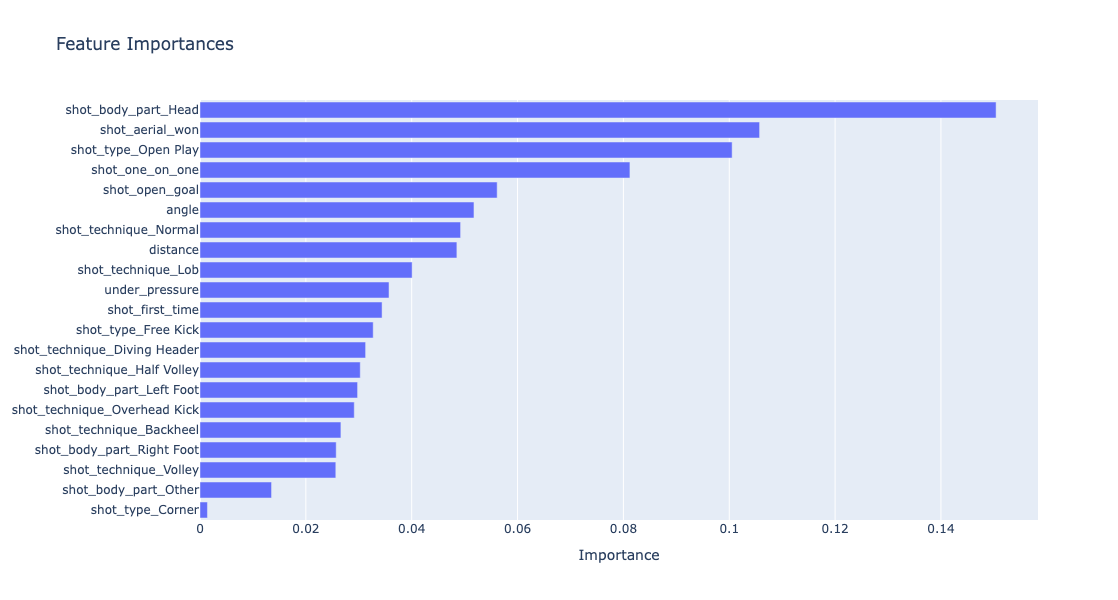

In [61]:
import plotly.graph_objects as go

importances = pd.Series(
  model.feature_importances_,
  index=feature_cols
).sort_values(ascending=True)

fig = go.Figure(go.Bar(
  x=importances.values,
  y=importances.index,
  orientation="h"
))

fig.update_layout(
  title="Feature Importances",
  xaxis_title="Importance",
  height=600
)

fig.show()

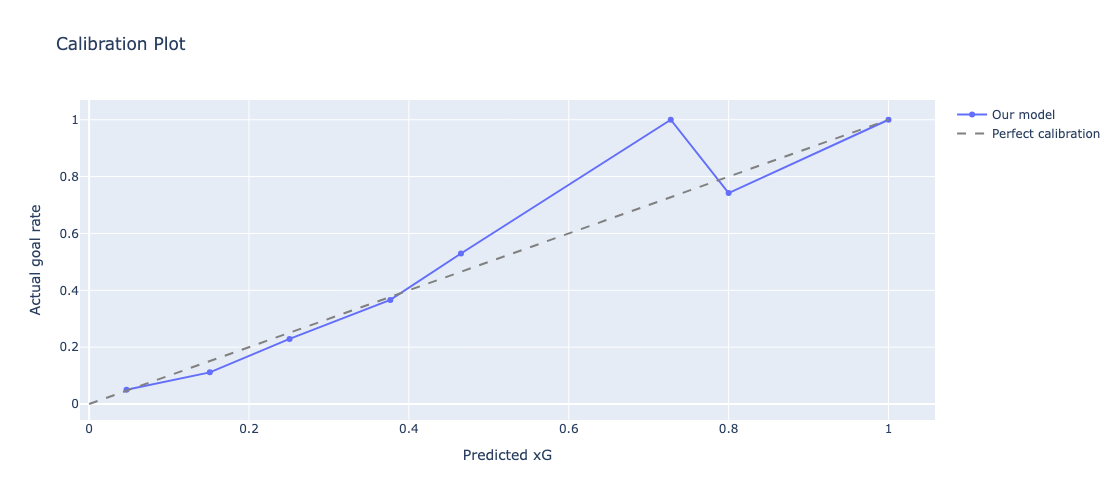

In [63]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_eval, y_pred_calibrated, n_bins=10)

fig = go.Figure()

fig.add_trace(go.Scatter(
  x=prob_pred, y=prob_true,
  mode="lines+markers",
  name="Our model"
))

fig.add_trace(go.Scatter(
  x=[0, 1], y=[0, 1],
  mode="lines",
  name="Perfect calibration",
  line=dict(dash="dash", color="gray")
))

fig.update_layout(
  title="Calibration Plot",
  xaxis_title="Predicted xG",
  yaxis_title="Actual goal rate",
  width=600,
  height=500
)

fig.show()

In [65]:
import joblib

joblib.dump(calibrated_model, "xg_model.pkl")
joblib.dump(feature_cols, "xg_feature_cols.pkl")

print("Model saved.")


Model saved.
